# ChurnSense — Phase 2
## Multi-Horizon Temporal Predictions · Risk Trajectories · ROI Optimizer

**Building on Phase 1's multi-class churn model:**

| Question | Phase 1 | Phase 2 |
|---|---|---|
| *Who* is at risk? | ✅ 4-class prediction | ✅ (inherited) |
| *When* will they churn? | ❌ | ✅ 30 / 60 / 90-day horizons |
| *How fast* is risk escalating? | ❌ | ✅ trajectory classification |
| *Who do we contact first?* | ❌ | ✅ budget-constrained ROI optimizer |
| *Interactive dashboard?* | ❌ | ✅ Streamlit (runs via `streamlit run app.py`) |

**Temporal approach:** We simulate customer feature evolution by projecting
tenure and charge accumulation forward. The Phase 1 XGBoost model — which
learned that different feature profiles carry different risk — naturally
produces different predictions when fed future-state features.


## 1  Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
import joblib
import json
import os
import warnings

warnings.filterwarnings('ignore')
os.makedirs('outputs/plots', exist_ok=True)
os.makedirs('src', exist_ok=True)

plt.rcParams.update({
    'figure.figsize'   : (14, 5),
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 12,
})
sns.set_style('whitegrid')

CLASS_NAMES  = ['Loyal', 'At-Risk', 'Critical', 'Will-Churn']
CLASS_COLORS = ['#2a78d6', '#1baf7a', '#eda100', '#e34948']
CLASS_MAP    = {0: 'Loyal', 1: 'At-Risk', 2: 'Critical', 3: 'Will-Churn'}
TRAJ_COLORS  = {
    'Stable'          : '#2a78d6',
    'Improving'       : '#1baf7a',
    'Escalating'      : '#eda100',
    'Rapid Escalation': '#e34948',
}

print('Setup complete.')


Setup complete.


## 2  Load Data & Replicate Phase 1 Preprocessing

In [2]:
df = pd.read_excel('data/Telco_customer_churn.xlsx')
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'].fillna(df['Monthly Charges'], inplace=True)

df_raw = df.copy()  # keep originals for display later

# ── 4-class target (same as Phase 1) ────────────────────────
def assign_class(score):
    if score <= 25:   return 0
    elif score <= 50: return 1
    elif score <= 75: return 2
    else:             return 3

df['Churn Class'] = df['Churn Score'].apply(assign_class)

# ── Drop leakage + geo columns ───────────────────────────────
LEAKAGE = ['Churn Label', 'Churn Value', 'Churn Score', 'Churn Reason', 'Churn Class Name']
GEO     = ['CustomerID', 'Count', 'Country', 'State', 'City',
           'Zip Code', 'Lat Long', 'Latitude', 'Longitude']
EXTRA   = ['Segment', 'Segment Name', 'Tenure Group', '_sc']

df_model  = df.copy()
drop_cols = [c for c in LEAKAGE + GEO + EXTRA if c in df_model.columns]
df_model.drop(columns=drop_cols, inplace=True)

# ── Feature engineering (must match Phase 1 exactly) ────────
svc_cols = [c for c in ['Online Security', 'Online Backup', 'Device Protection',
                          'Tech Support', 'Streaming TV', 'Streaming Movies']
            if c in df_model.columns]

df_model['Charge per Tenure'] = df_model['Monthly Charges'] / (df_model['Tenure Months'] + 1)
df_model['Revenue Share']     = df_model['Monthly Charges'] / df_model['Monthly Charges'].max()
df_model['Service Count']     = (df_model[svc_cols] == 'Yes').sum(axis=1)

# ── Encode categoricals ──────────────────────────────────────
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
le_dict  = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col]  = le

TARGET   = 'Churn Class'
FEATURES = [c for c in df_model.columns if c != TARGET]
X        = df_model[FEATURES]
y        = df_model[TARGET]

print(f'Customers : {len(df_model):,}')
print(f'Features  : {len(FEATURES)}')
print(f'Encoders  : {len(le_dict)} categorical columns encoded')


Customers : 7,043
Features  : 23
Encoders  : 16 categorical columns encoded


In [5]:
# ── Load Phase 1 model (or retrain if pkl missing) ──────────
MODEL_PATH = 'outputs/model_phase1.pkl'

if os.path.exists(MODEL_PATH):
    model_base = joblib.load(MODEL_PATH)
    print('Loaded Phase 1 model from disk.')
else:
    print('Phase 1 model not found — retraining...')
    COST_MATRIX = np.array([
        [  0, 10, 25,  60],
        [ 30,  0, 10,  40],
        [ 80, 25,  0,  20],
        [200, 80, 40,   0],
    ])
    def sample_weights(y_arr, cm):
        w = []
        for cls in y_arr:
            row = cm[int(cls)].astype(float).copy(); row[int(cls)] = 0.0
            w.append(row[row > 0].mean())
        return np.array(w)

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                                random_state=42, stratify=y)
    X_res, y_res = SMOTE(random_state=42, k_neighbors=3).fit_resample(X_tr, y_tr)

    model_base = XGBClassifier(
        n_estimators=400, max_depth=6, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
        objective='multi:softmax', num_class=4, eval_metric='mlogloss',
        random_state=42, n_jobs=-1, verbosity=0,
    )
    model_base.fit(X_res, y_res,
                   sample_weight=sample_weights(y_res, COST_MATRIX),
                   verbose=False)
    joblib.dump(model_base, MODEL_PATH)
    print('Model retrained and saved.')

print('Base model ready.')


Loaded Phase 1 model from disk.
Base model ready.


## 3  Temporal Feature Engineering

### How it works

We "fast-forward" each customer's profile by N months, then re-run predictions.

| Feature | Projection rule |
|---|---|
| `Tenure Months` | `+ N` |
| `Total Charges` | `+ Monthly Charges × N` (charges accumulate every month) |
| `Charge per Tenure` | Recalculated — ratio improves as tenure grows |
| `Revenue Share` | Recalculated |
| All other features | **Unchanged** — contract, services, payment don't change unless the customer acts |

**Why this is defensible:** XGBoost learned from data that new customers
(low tenure, lower total charges) churn more than long-term customers.
By projecting features forward, we let the model answer: "given where
this customer will be in 60 days, what risk class do they fall into?"


In [6]:
def perturb_features(df_X, horizon_months):
    """Project feature values horizon_months into the future."""
    df_h = df_X.copy()
    if horizon_months == 0:
        return df_h[FEATURES]

    if 'Tenure Months' in df_h.columns:
        df_h['Tenure Months'] = df_h['Tenure Months'] + horizon_months

    if 'Total Charges' in df_h.columns and 'Monthly Charges' in df_h.columns:
        df_h['Total Charges'] = df_h['Total Charges'] + df_h['Monthly Charges'] * horizon_months

    if 'Monthly Charges' in df_h.columns and 'Tenure Months' in df_h.columns:
        df_h['Charge per Tenure'] = df_h['Monthly Charges'] / (df_h['Tenure Months'] + 1)

    if 'Monthly Charges' in df_h.columns:
        df_h['Revenue Share'] = df_h['Monthly Charges'] / df_h['Monthly Charges'].max()

    return df_h[FEATURES]

# Create feature sets for each horizon
X_h30 = perturb_features(X, horizon_months=0)   # current state
X_h60 = perturb_features(X, horizon_months=2)   # +2 months
X_h90 = perturb_features(X, horizon_months=3)   # +3 months

# Show what changes
for feat in ['Tenure Months', 'Total Charges', 'Charge per Tenure']:
    v30 = X_h30[feat].mean()
    v60 = X_h60[feat].mean()
    v90 = X_h90[feat].mean()
    print(f'{feat:22s}  H30={v30:8.2f}  H60={v60:8.2f}  H90={v90:8.2f}')

avg_mc = X['Monthly Charges'].mean()
print(f'\nAvg monthly charges: ${avg_mc:.2f}')
print(f'  H60 adds ${avg_mc*2:.0f} to Total Charges per customer on average')
print(f'  H90 adds ${avg_mc*3:.0f} to Total Charges per customer on average')


Tenure Months           H30=   32.37  H60=   34.37  H90=   35.37
Total Charges           H30= 2279.80  H60= 2409.32  H90= 2474.08
Charge per Tenure       H30=    5.77  H60=    3.90  H90=    3.44

Avg monthly charges: $64.76
  H60 adds $130 to Total Charges per customer on average
  H90 adds $194 to Total Charges per customer on average


## 4  Multi-Horizon Predictions

In [7]:
# ── Generate predictions at all 3 horizons ──────────────────
pred_h30  = model_base.predict(X_h30)
pred_h60  = model_base.predict(X_h60)
pred_h90  = model_base.predict(X_h90)
proba_h30 = model_base.predict_proba(X_h30)

df_preds = pd.DataFrame({
    'Pred_H30'      : pred_h30,
    'Pred_H60'      : pred_h60,
    'Pred_H90'      : pred_h90,
    'Pred_H30_Name' : [CLASS_MAP[p] for p in pred_h30],
    'Pred_H60_Name' : [CLASS_MAP[p] for p in pred_h60],
    'Pred_H90_Name' : [CLASS_MAP[p] for p in pred_h90],
    'P_Loyal'       : proba_h30[:, 0],
    'P_AtRisk'      : proba_h30[:, 1],
    'P_Critical'    : proba_h30[:, 2],
    'P_WillChurn'   : proba_h30[:, 3],
    'Monthly Charges': df_raw['Monthly Charges'].values,
    'CLTV'          : df_raw['CLTV'].values,
    'Tenure Months' : df_raw['Tenure Months'].values,
    'Contract'      : df_raw['Contract'].values,
})

for col, label in [('Pred_H30_Name','30-day'), ('Pred_H60_Name','60-day'), ('Pred_H90_Name','90-day')]:
    counts = df_preds[col].value_counts().reindex(CLASS_NAMES).fillna(0)
    print(f'\n{label} predictions:')
    for cls, n in counts.items():
        print(f'  {cls:14s}: {int(n):>5,}  ({n/len(df_preds):.1%})')



30-day predictions:
  Loyal         :   447  (6.3%)
  At-Risk       : 1,707  (24.2%)
  Critical      : 2,580  (36.6%)
  Will-Churn    : 2,309  (32.8%)

60-day predictions:
  Loyal         :   339  (4.8%)
  At-Risk       : 1,402  (19.9%)
  Critical      : 2,613  (37.1%)
  Will-Churn    : 2,689  (38.2%)

90-day predictions:
  Loyal         :   320  (4.5%)
  At-Risk       : 1,427  (20.3%)
  Critical      : 2,591  (36.8%)
  Will-Churn    : 2,705  (38.4%)


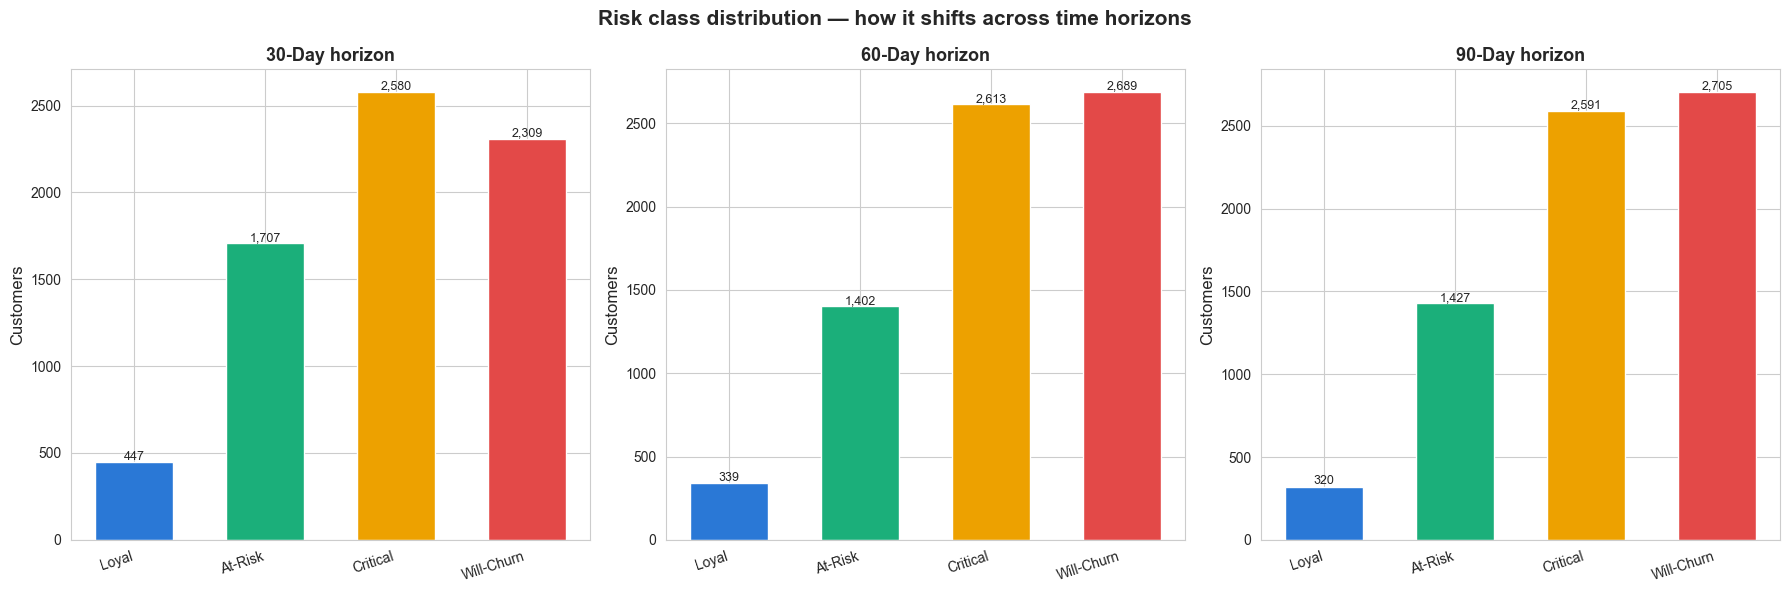

Will-Churn at 30d: 2,309
Will-Churn at 90d: 2,705  (Δ +396)


In [8]:
# ── Chart: Class distribution across 3 horizons ─────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (col, label) in zip(axes, [('Pred_H30_Name','30-Day'),
                                     ('Pred_H60_Name','60-Day'),
                                     ('Pred_H90_Name','90-Day')]):
    cnts = df_preds[col].value_counts().reindex(CLASS_NAMES).fillna(0)
    bars = ax.bar(CLASS_NAMES, cnts.values,
                  color=CLASS_COLORS, edgecolor='white', width=0.6)
    ax.set_title(f'{label} horizon', fontsize=13)
    ax.set_ylabel('Customers')
    ax.set_xticklabels(CLASS_NAMES, rotation=18, ha='right')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 15,
                f'{int(bar.get_height()):,}',
                ha='center', fontsize=9)

plt.suptitle('Risk class distribution — how it shifts across time horizons',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/p2_01_temporal_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

h30_wc = int((df_preds['Pred_H30'] == 3).sum())
h90_wc = int((df_preds['Pred_H90'] == 3).sum())
print(f'Will-Churn at 30d: {h30_wc:,}')
print(f'Will-Churn at 90d: {h90_wc:,}  (Δ {h90_wc - h30_wc:+,})')


## 5  Risk Trajectory Classification

Each customer gets a trajectory label based on how their predicted risk
class changes from 30 → 90 days:

| Label | Condition | Priority |
|---|---|---|
| **Stable** | H30 == H90 | Normal monitoring |
| **Improving** | H90 < H30 | Good — continue engagement |
| **Escalating** | H90 == H30 + 1 | High — intervene this week |
| **Rapid Escalation** | H90 ≥ H30 + 2 | Urgent — contact within 48 h |


In [9]:
def classify_trajectory(h30, h60, h90):
    delta = int(h90) - int(h30)
    if delta >= 2:   return 'Rapid Escalation'
    elif delta == 1: return 'Escalating'
    elif delta == 0: return 'Stable'
    else:            return 'Improving'

df_preds['Trajectory'] = df_preds.apply(
    lambda r: classify_trajectory(r['Pred_H30'], r['Pred_H60'], r['Pred_H90']),
    axis=1,
)
df_preds['Risk_Delta'] = df_preds['Pred_H90'].astype(int) - df_preds['Pred_H30'].astype(int)

traj_counts = df_preds['Trajectory'].value_counts()
print('Trajectory distribution:')
for traj, n in traj_counts.items():
    print(f'  {traj:20s}: {n:>5,}  ({n/len(df_preds):.1%})')

total_esc = int(traj_counts.get('Escalating', 0) + traj_counts.get('Rapid Escalation', 0))
print(f'\nTotal escalating risk  : {total_esc:,} ({total_esc/len(df_preds):.1%})')
print(f'Monthly revenue at risk: ${df_preds[df_preds["Trajectory"].isin(["Escalating","Rapid Escalation"])]["Monthly Charges"].sum():,.0f}')


Trajectory distribution:
  Stable              : 5,374  (76.3%)
  Escalating          :   730  (10.4%)
  Improving           :   529  (7.5%)
  Rapid Escalation    :   410  (5.8%)

Total escalating risk  : 1,140 (16.2%)
Monthly revenue at risk: $72,502


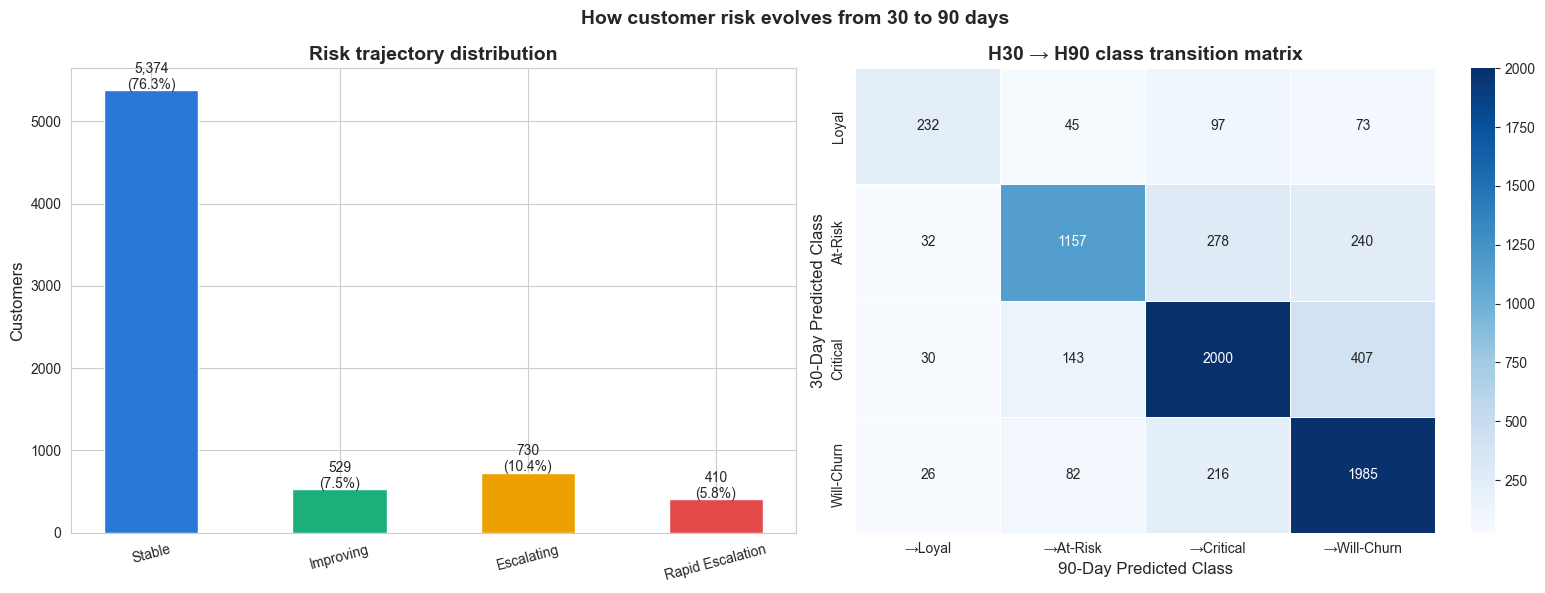

In [10]:
# ── Chart: Trajectory bar + transition heatmap ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

traj_order = ['Stable', 'Improving', 'Escalating', 'Rapid Escalation']
traj_vals  = [int(traj_counts.get(t, 0)) for t in traj_order]
traj_clrs  = [TRAJ_COLORS[t] for t in traj_order]

bars = axes[0].bar(traj_order, traj_vals,
                   color=traj_clrs, edgecolor='white', width=0.5)
for bar, v in zip(bars, traj_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 15,
                 f'{v:,}\n({v/len(df_preds):.1%})',
                 ha='center', fontsize=10)
axes[0].set_title('Risk trajectory distribution')
axes[0].set_ylabel('Customers')
axes[0].tick_params(axis='x', rotation=15)

# H30 → H90 transition matrix
trans = np.zeros((4, 4), dtype=int)
for _, row in df_preds.iterrows():
    trans[int(row['Pred_H30'])][int(row['Pred_H90'])] += 1

sns.heatmap(trans, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'→{c}' for c in CLASS_NAMES],
            yticklabels=CLASS_NAMES,
            ax=axes[1], linewidths=0.5, annot_kws={'size': 10})
axes[1].set_title('H30 → H90 class transition matrix')
axes[1].set_xlabel('90-Day Predicted Class')
axes[1].set_ylabel('30-Day Predicted Class')

plt.suptitle('How customer risk evolves from 30 to 90 days',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/p2_02_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# ── Sankey: H30 → H90 risk flow ─────────────────────────────
from_nodes = [f'{c} (30d)' for c in CLASS_NAMES]
to_nodes   = [f'{c} (90d)' for c in CLASS_NAMES]

hex_rgba = lambda h, a: f'rgba({int(h[1:3],16)},{int(h[3:5],16)},{int(h[5:7],16)},{a})'

srcs, tgts, vals, lclrs = [], [], [], []
for i in range(4):
    for j in range(4):
        n = int(trans[i][j])
        if n > 5:
            srcs.append(i); tgts.append(4 + j); vals.append(n)
            lclrs.append(hex_rgba(CLASS_COLORS[i], 0.35))

fig_sk = go.Figure(go.Sankey(
    node=dict(
        label=from_nodes + to_nodes,
        color=CLASS_COLORS * 2,
        pad=20, thickness=22,
    ),
    link=dict(source=srcs, target=tgts, value=vals, color=lclrs),
))
fig_sk.update_layout(
    title_text='Customer Risk Flow: 30-Day → 90-Day Horizon',
    title_font_size=15,
    height=460,
    margin=dict(l=20, r=20, t=60, b=20),
)
fig_sk.show()
fig_sk.write_image('outputs/plots/p2_03_sankey.png', scale=2)
print('Sankey saved.')


Sankey saved.


In [12]:
# ── Top escalating customers ─────────────────────────────────
escalating = df_preds[
    df_preds['Trajectory'].isin(['Escalating', 'Rapid Escalation'])
].copy()

escalating_sorted = (escalating
    .sort_values(['Risk_Delta', 'Monthly Charges'], ascending=[False, False])
    .reset_index(drop=True))

print(f'Escalating customers  : {len(escalating_sorted):,}')
print(f'Revenue tied (monthly): ${escalating_sorted["Monthly Charges"].sum():,.0f}')
print()
print('Top 10 by severity + monthly charges:')
show_cols = ['Pred_H30_Name', 'Pred_H60_Name', 'Pred_H90_Name',
             'Trajectory', 'Monthly Charges', 'CLTV', 'Contract']
print(escalating_sorted[show_cols].head(10).to_string(index=False))


Escalating customers  : 1,140
Revenue tied (monthly): $72,502

Top 10 by severity + monthly charges:
Pred_H30_Name Pred_H60_Name Pred_H90_Name       Trajectory  Monthly Charges  CLTV       Contract
        Loyal    Will-Churn    Will-Churn Rapid Escalation           109.65  4676 Month-to-month
        Loyal    Will-Churn    Will-Churn Rapid Escalation           107.45  5446       One year
        Loyal    Will-Churn    Will-Churn Rapid Escalation           105.15  5915 Month-to-month
        Loyal    Will-Churn    Will-Churn Rapid Escalation           104.50  4812       One year
        Loyal    Will-Churn    Will-Churn Rapid Escalation           104.35  4934 Month-to-month
        Loyal    Will-Churn    Will-Churn Rapid Escalation           103.75  3568       One year
        Loyal    Will-Churn    Will-Churn Rapid Escalation           103.05  5586 Month-to-month
        Loyal    Will-Churn    Will-Churn Rapid Escalation            99.50  4001 Month-to-month
        Loyal    Will-Chur

## 6  ROI-Driven Intervention Optimizer

### Why "contact all at-risk" doesn't scale

With 4,000+ at-risk customers, blanket outreach wastes budget on
low-value contacts. We need a way to rank customers so every dollar
of intervention budget delivers maximum revenue recovery.

### Scoring formula

```
Expected Annual Revenue at Risk = Monthly Charges × 12 × risk_weight
Expected ROI (if contacted)     = Revenue at Risk × save_rate
Net ROI                         = Expected ROI − cost_per_contact
```

Sort by Net ROI descending → take the top N = budget / cost_per_contact
customers. This greedy ranking is optimal for independent customers.

Risk weights (probability of churning per class):
`Loyal: 2%  |  At-Risk: 15%  |  Critical: 50%  |  Will-Churn: 85%`


In [13]:
RISK_WEIGHTS   = {0: 0.02, 1: 0.15, 2: 0.50, 3: 0.85}
COST_PER_CONT  = 50        # USD per customer contacted
SAVE_RATE      = 0.30      # 30% of contacted customers saved
BUDGET         = 100_000   # total USD budget

df_preds['Risk Weight']     = df_preds['Pred_H30'].map(RISK_WEIGHTS)
df_preds['Revenue at Risk'] = df_preds['Monthly Charges'] * 12 * df_preds['Risk Weight']
df_preds['Expected ROI']    = df_preds['Revenue at Risk'] * SAVE_RATE

# Only contact at-risk customers (class >= 1)
at_risk = df_preds[df_preds['Pred_H30'] >= 1].copy()
at_risk = at_risk.sort_values('Expected ROI', ascending=False).reset_index(drop=True)

max_contacts = int(BUDGET / COST_PER_CONT)
to_contact   = at_risk.head(max_contacts).copy()
to_contact['Priority Rank']            = range(1, len(to_contact) + 1)
to_contact['Net ROI']                  = to_contact['Expected ROI'] - COST_PER_CONT
to_contact['Cumulative Revenue Saved'] = (to_contact['Revenue at Risk'] * SAVE_RATE).cumsum()
to_contact['Cumulative Spend']         = to_contact['Priority Rank'] * COST_PER_CONT

rev_saved    = float(to_contact['Revenue at Risk'].sum() * SAVE_RATE)
total_spend  = len(to_contact) * COST_PER_CONT
net_gain     = rev_saved - total_spend
roi_multiple = rev_saved / max(total_spend, 1)

print(f'Budget                  : ${BUDGET:,}')
print(f'Cost per contact        : ${COST_PER_CONT}')
print(f'Save rate               : {SAVE_RATE:.0%}')
print(f'At-risk customers       : {len(at_risk):,}')
print(f'Customers to contact    : {len(to_contact):,}')
print(f'Expected customers saved: {int(len(to_contact) * SAVE_RATE):,}')
print(f'Annual revenue saved    : ${rev_saved:,.0f}')
print(f'Total intervention spend: ${total_spend:,}')
print(f'Net annual gain         : ${net_gain:,.0f}')
print(f'ROI multiple            : {roi_multiple:.1f}×')


Budget                  : $100,000
Cost per contact        : $50
Save rate               : 30%
At-risk customers       : 6,596
Customers to contact    : 2,000
Expected customers saved: 600
Annual revenue saved    : $499,163
Total intervention spend: $100,000
Net annual gain         : $399,163
ROI multiple            : 5.0×


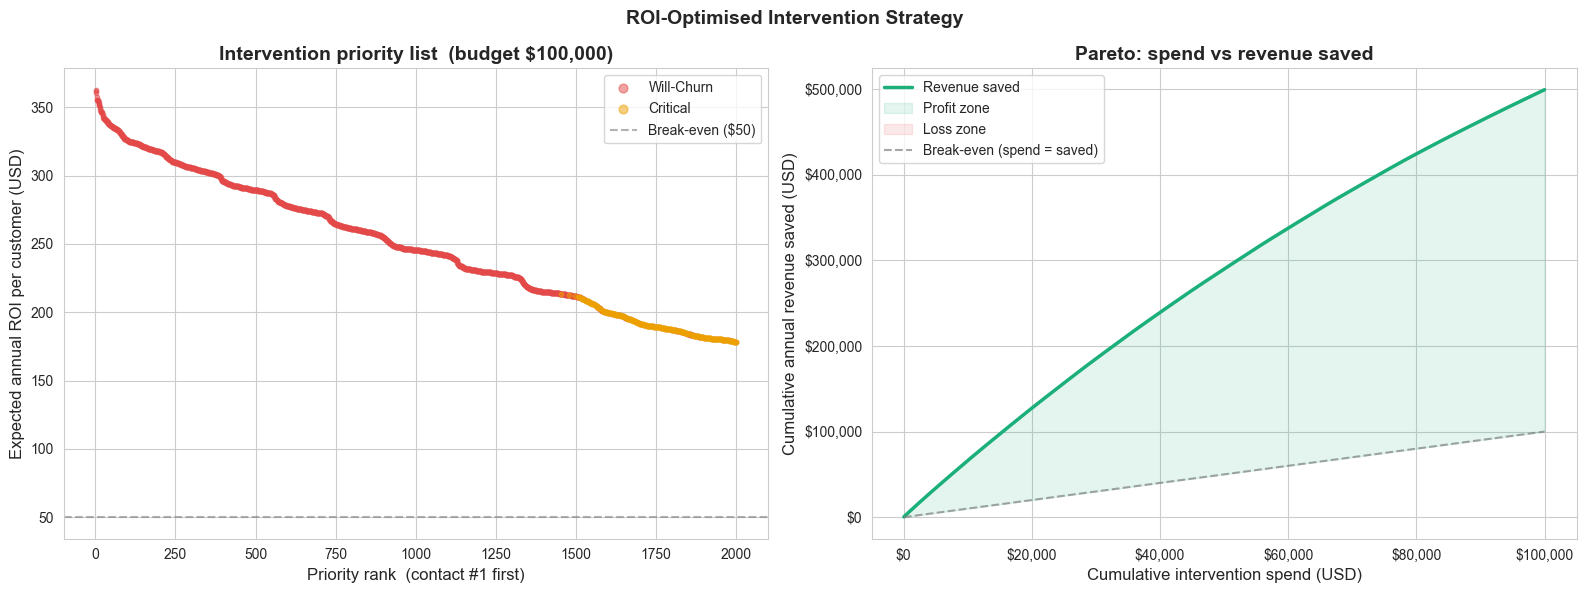

In [14]:
# ── Chart: Priority list + cumulative Pareto ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Priority scatter: rank vs expected ROI, coloured by class
for cls in [3, 2, 1, 0]:
    sub = to_contact[to_contact['Pred_H30'] == cls]
    if len(sub) > 0:
        axes[0].scatter(sub['Priority Rank'], sub['Expected ROI'],
                        c=CLASS_COLORS[cls], alpha=0.5, s=10, label=CLASS_MAP[cls])
axes[0].axhline(COST_PER_CONT, linestyle='--', color='gray',
                alpha=0.6, label='Break-even ($50)')
axes[0].set_xlabel('Priority rank  (contact #1 first)')
axes[0].set_ylabel('Expected annual ROI per customer (USD)')
axes[0].set_title(f'Intervention priority list  (budget ${BUDGET:,})')
axes[0].legend(markerscale=2)

# Cumulative: spend vs revenue saved
n_pt   = len(to_contact)
cum_sp = np.arange(1, n_pt + 1) * COST_PER_CONT
cum_rv = (to_contact['Revenue at Risk'] * SAVE_RATE).cumsum().values

axes[1].plot(cum_sp, cum_rv, color='#1baf7a', linewidth=2.5, label='Revenue saved')
axes[1].fill_between(cum_sp, cum_sp, cum_rv,
                     where=(cum_rv > cum_sp), alpha=0.12, color='#1baf7a',
                     label='Profit zone')
axes[1].fill_between(cum_sp, cum_sp, cum_rv,
                     where=(cum_rv < cum_sp), alpha=0.12, color='#e34948',
                     label='Loss zone')
axes[1].plot(cum_sp, cum_sp, '--', color='gray', alpha=0.7,
             label='Break-even (spend = saved)')
axes[1].set_xlabel('Cumulative intervention spend (USD)')
axes[1].set_ylabel('Cumulative annual revenue saved (USD)')
axes[1].set_title('Pareto: spend vs revenue saved')
axes[1].legend()
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('ROI-Optimised Intervention Strategy',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/p2_04_roi_optimizer.png', dpi=150, bbox_inches='tight')
plt.show()


## 7  Budget Sensitivity Analysis

In [15]:
budgets = [10_000, 25_000, 50_000, 75_000, 100_000,
           150_000, 200_000, 250_000, 300_000]
rows = []
for b in budgets:
    n_max  = int(b / COST_PER_CONT)
    sub    = at_risk.head(n_max)
    r_save = float(sub['Revenue at Risk'].sum() * SAVE_RATE)
    spend  = len(sub) * COST_PER_CONT
    rows.append({
        'Budget'                 : b,
        'Customers Contacted'    : len(sub),
        'Customers Saved'        : int(len(sub) * SAVE_RATE),
        'Revenue Saved (Annual)' : r_save,
        'Total Spend'            : spend,
        'Net Annual Gain'        : r_save - spend,
        'ROI Multiple'           : round(r_save / max(spend, 1), 2),
    })

sensitivity_df = pd.DataFrame(rows)
print(sensitivity_df[['Budget','Customers Contacted',
                       'Revenue Saved (Annual)','Net Annual Gain','ROI Multiple']].to_string(index=False))


 Budget  Customers Contacted  Revenue Saved (Annual)  Net Annual Gain  ROI Multiple
  10000                  200               65979.567        55979.567          6.60
  25000                  500              156433.779       131433.779          6.26
  50000                 1000              289661.742       239661.742          5.79
  75000                 1500              403620.579       328620.579          5.38
 100000                 2000              499162.833       399162.833          4.99
 150000                 3000              654809.436       504809.436          4.37
 200000                 4000              757086.858       557086.858          3.79
 250000                 5000              809245.035       559245.035          3.24
 300000                 6000              843790.545       543790.545          2.81


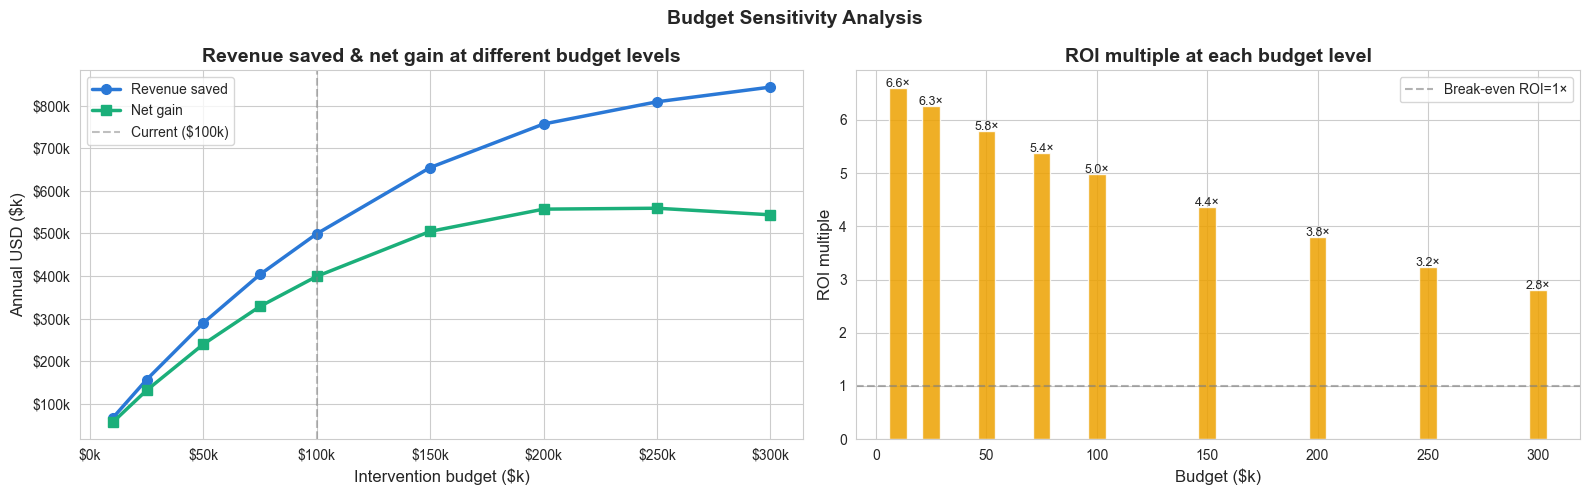

In [16]:
# ── Chart: Budget sensitivity curves ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(sensitivity_df['Budget']/1e3,
             sensitivity_df['Revenue Saved (Annual)']/1e3,
             'o-', color='#2a78d6', linewidth=2.5, markersize=7, label='Revenue saved')
axes[0].plot(sensitivity_df['Budget']/1e3,
             sensitivity_df['Net Annual Gain']/1e3,
             's-', color='#1baf7a', linewidth=2.5, markersize=7, label='Net gain')
axes[0].axvline(BUDGET/1e3, linestyle='--', color='gray', alpha=0.5,
                label=f'Current (${BUDGET/1e3:.0f}k)')
axes[0].set_xlabel('Intervention budget ($k)')
axes[0].set_ylabel('Annual USD ($k)')
axes[0].set_title('Revenue saved & net gain at different budget levels')
axes[0].legend()
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}k'))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}k'))

axes[1].bar(sensitivity_df['Budget']/1e3,
            sensitivity_df['ROI Multiple'],
            width=8, color='#eda100', alpha=0.85, edgecolor='white')
axes[1].axhline(1, linestyle='--', color='gray', alpha=0.6, label='Break-even ROI=1×')
for _, row in sensitivity_df.iterrows():
    axes[1].text(row['Budget']/1e3, row['ROI Multiple'] + 0.02,
                 f'{row["ROI Multiple"]:.1f}×', ha='center', fontsize=9)
axes[1].set_xlabel('Budget ($k)')
axes[1].set_ylabel('ROI multiple')
axes[1].set_title('ROI multiple at each budget level')
axes[1].legend()

plt.suptitle('Budget Sensitivity Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/p2_05_budget_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


## 8  Phase 2 Business Impact Summary

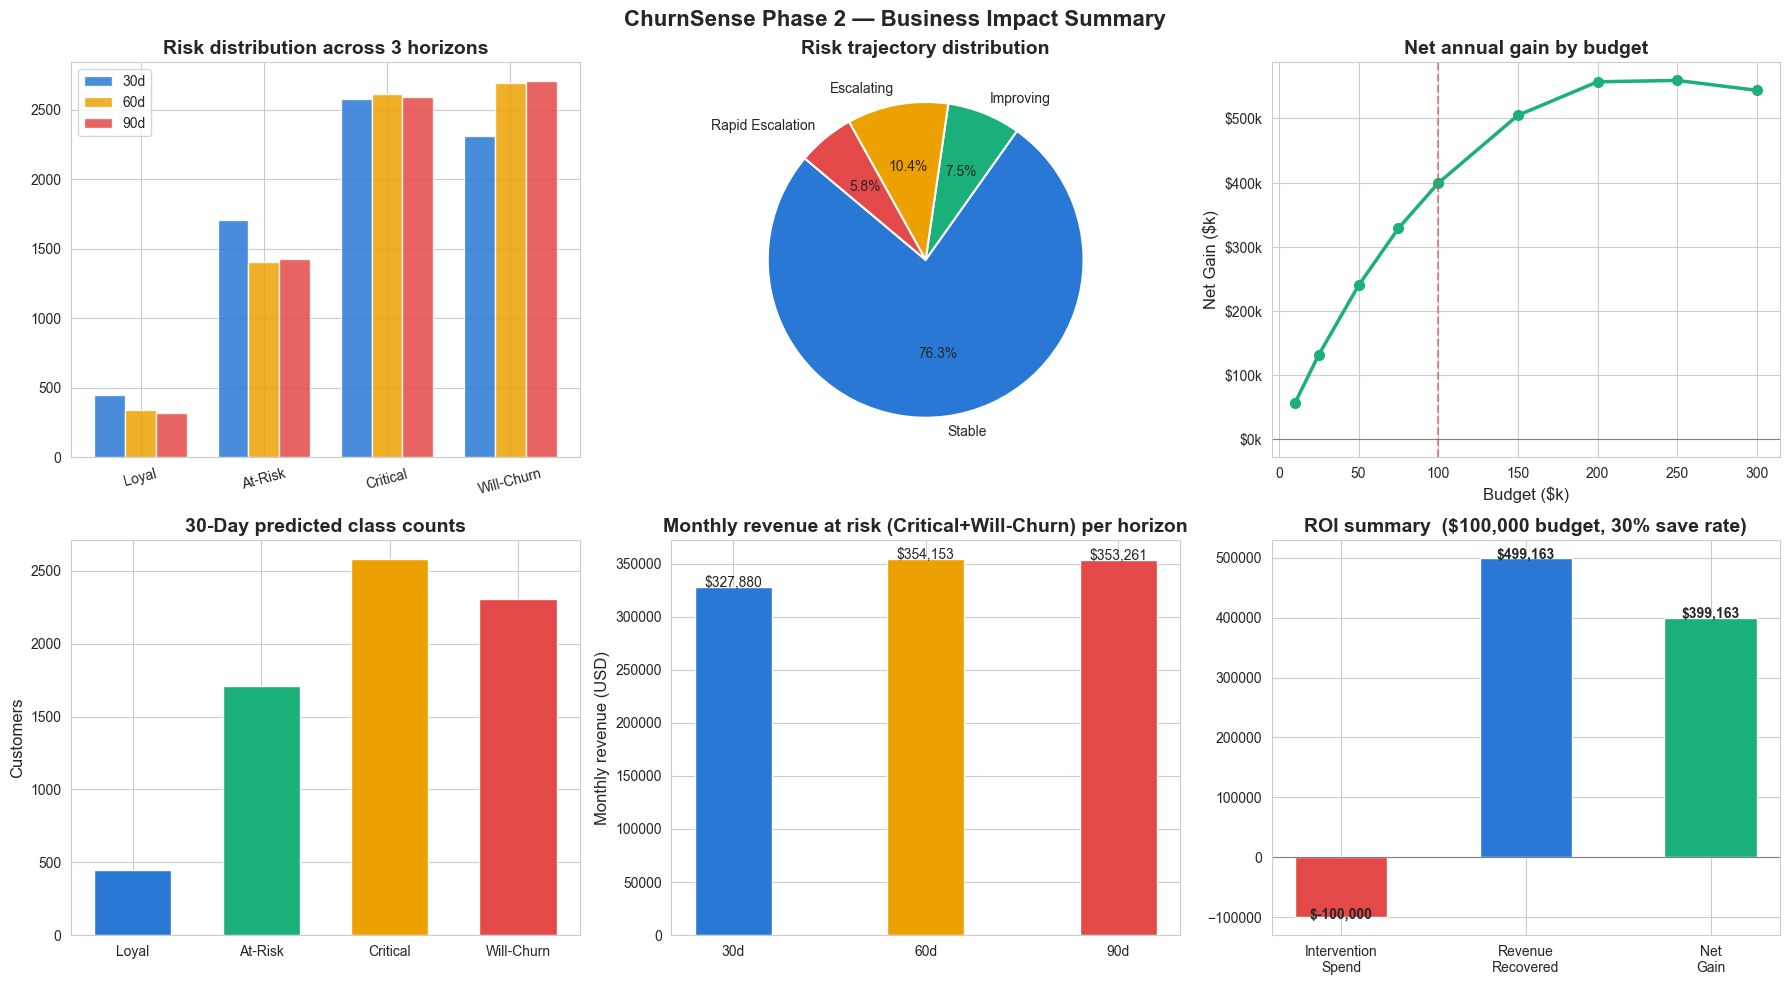


CHURNSENSE PHASE 2 — EXECUTIVE SUMMARY
  Total customers analysed         : 7,043
  Will-Churn (30d)                 : 2,309
  Will-Churn (90d)                 : 2,705
  Escalating trajectories          : 1,140 (16.2%)
  Monthly revenue at risk (30d)    : $327,880
  Recommended contacts ($100k)     : 2,000
  Expected annual revenue saved    : $499,163
  Estimated ROI                    : 5.0×


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# [0,0] Grouped bar: distributions across 3 horizons
x = np.arange(len(CLASS_NAMES)); w = 0.25
for i, (col, label, clr) in enumerate([
    ('Pred_H30_Name','30d','#2a78d6'),
    ('Pred_H60_Name','60d','#eda100'),
    ('Pred_H90_Name','90d','#e34948'),
]):
    cnts = df_preds[col].value_counts().reindex(CLASS_NAMES).fillna(0)
    axes[0,0].bar(x+(i-1)*w, cnts.values, w,
                  label=label, color=clr, alpha=0.85, edgecolor='white')
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(CLASS_NAMES, rotation=15)
axes[0,0].set_title('Risk distribution across 3 horizons'); axes[0,0].legend()

# [0,1] Trajectory pie
traj_order = ['Stable','Improving','Escalating','Rapid Escalation']
axes[0,1].pie(
    [traj_counts.get(t, 0) for t in traj_order],
    labels=traj_order,
    colors=[TRAJ_COLORS[t] for t in traj_order],
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':1.5},
)
axes[0,1].set_title('Risk trajectory distribution')

# [0,2] Budget → net gain
axes[0,2].plot(sensitivity_df['Budget']/1e3,
               sensitivity_df['Net Annual Gain']/1e3,
               'o-', color='#1baf7a', linewidth=2.5, markersize=7)
axes[0,2].axhline(0, color='gray', linewidth=0.8)
axes[0,2].axvline(BUDGET/1e3, linestyle='--', color='#e34948', alpha=0.6)
axes[0,2].set_title('Net annual gain by budget')
axes[0,2].set_xlabel('Budget ($k)'); axes[0,2].set_ylabel('Net Gain ($k)')
axes[0,2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}k'))

# [1,0] 30d class bar
cnts30 = df_preds['Pred_H30_Name'].value_counts().reindex(CLASS_NAMES).fillna(0)
axes[1,0].bar(CLASS_NAMES, cnts30.values,
              color=CLASS_COLORS, edgecolor='white', width=0.6)
axes[1,0].set_title('30-Day predicted class counts')
axes[1,0].set_ylabel('Customers')

# [1,1] Revenue at risk per horizon (Critical + Will-Churn only)
rev_by_h = {}
for col, label in [('Pred_H30_Name','30d'),('Pred_H60_Name','60d'),('Pred_H90_Name','90d')]:
    r = df_preds[df_preds[col].isin(['Critical','Will-Churn'])]['Monthly Charges'].sum()
    rev_by_h[label] = r
axes[1,1].bar(rev_by_h.keys(), rev_by_h.values(),
              color=['#2a78d6','#eda100','#e34948'], edgecolor='white', width=0.4)
for i, v in enumerate(rev_by_h.values()):
    axes[1,1].text(i, v+200, f'${v:,.0f}', ha='center', fontsize=10)
axes[1,1].set_title('Monthly revenue at risk (Critical+Will-Churn) per horizon')
axes[1,1].set_ylabel('Monthly revenue (USD)')

# [1,2] ROI bars
cats = ['Intervention\nSpend', 'Revenue\nRecovered', 'Net\nGain']
vals = [-total_spend, rev_saved, net_gain]
clrs = ['#e34948', '#2a78d6', '#1baf7a']
axes[1,2].bar(cats, vals, color=clrs, edgecolor='white', width=0.5)
for i, v in enumerate(vals):
    axes[1,2].text(i, v + (200 if v >= 0 else -2500), f'${v:,.0f}',
                   ha='center', fontsize=10, fontweight='bold')
axes[1,2].axhline(0, color='gray', linewidth=0.8)
axes[1,2].set_title(f'ROI summary  (${BUDGET:,} budget, {SAVE_RATE:.0%} save rate)')

plt.suptitle('ChurnSense Phase 2 — Business Impact Summary',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/plots/p2_06_phase2_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*65)
print('CHURNSENSE PHASE 2 — EXECUTIVE SUMMARY')
print('='*65)
print(f'  Total customers analysed         : {len(df_preds):,}')
print(f'  Will-Churn (30d)                 : {int((df_preds["Pred_H30"]==3).sum()):,}')
print(f'  Will-Churn (90d)                 : {int((df_preds["Pred_H90"]==3).sum()):,}')
print(f'  Escalating trajectories          : {total_esc:,} ({total_esc/len(df_preds):.1%})')
print(f'  Monthly revenue at risk (30d)    : ${df_preds[df_preds["Pred_H30"].isin([2,3])]["Monthly Charges"].sum():,.0f}')
print(f'  Recommended contacts ($100k)     : {len(to_contact):,}')
print(f'  Expected annual revenue saved    : ${rev_saved:,.0f}')
print(f'  Estimated ROI                    : {roi_multiple:.1f}×')
print('='*65)


## 9  Export Artifacts — Powers the Streamlit Dashboard

In [18]:
# ── 1. Full predictions CSV ──────────────────────────────────
df_preds.to_csv('outputs/phase2_predictions.csv', index=False)
print('✅ outputs/phase2_predictions.csv')

# ── 2. Raw feature matrix (for SHAP in dashboard) ───────────
X[FEATURES].to_csv('outputs/X_features.csv', index=False)
print('✅ outputs/X_features.csv')

# ── 3. Model artifacts ───────────────────────────────────────
for name in ['model_h30', 'model_h60', 'model_h90']:
    joblib.dump(model_base, f'outputs/{name}.pkl')
print('✅ outputs/model_h30/h60/h90.pkl')

joblib.dump(le_dict,  'outputs/label_encoders.pkl')
joblib.dump(FEATURES, 'outputs/feature_names.pkl')
print('✅ outputs/label_encoders.pkl')
print('✅ outputs/feature_names.pkl')

# ── 4. Summary stats JSON ────────────────────────────────────
summary = {
    'total_customers'   : int(len(df_preds)),
    'n_will_churn_30d'  : int((df_preds['Pred_H30'] == 3).sum()),
    'n_will_churn_90d'  : int((df_preds['Pred_H90'] == 3).sum()),
    'n_escalating'      : int(total_esc),
    'monthly_rev_risk'  : float(df_preds[df_preds['Pred_H30'].isin([2,3])]['Monthly Charges'].sum()),
    'annual_rev_saved'  : float(rev_saved),
    'roi_multiple'      : float(roi_multiple),
    'budget_used'       : BUDGET,
    'cost_per_contact'  : COST_PER_CONT,
    'save_rate'         : SAVE_RATE,
}
with open('outputs/summary_stats.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('✅ outputs/summary_stats.json')

print()
print('All artifacts saved. Launch the dashboard with:')
print('  streamlit run app.py')


✅ outputs/phase2_predictions.csv
✅ outputs/X_features.csv
✅ outputs/model_h30/h60/h90.pkl
✅ outputs/label_encoders.pkl
✅ outputs/feature_names.pkl
✅ outputs/summary_stats.json

All artifacts saved. Launch the dashboard with:
  streamlit run app.py
